In [24]:
#loading required modules#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:

#importing module dependencies#
from sklearn import neighbors, datasets, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [26]:
#loading the iris data set#
iris = datasets.load_iris()

In [27]:
#----trandform the data into a panda DataFrame and slicing out the first six columns/features---
df = pd.DataFrame(data=iris.data,
                  columns=iris.feature_names)


In [28]:
####looking at the schemer of the df###
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [29]:
#####loading the summary stats####
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [30]:
#### selecting the first six rows of the df###
print('first six rows:' + str( df.head(6)))

first six rows:   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
5                5.4               3.9                1.7               0.4


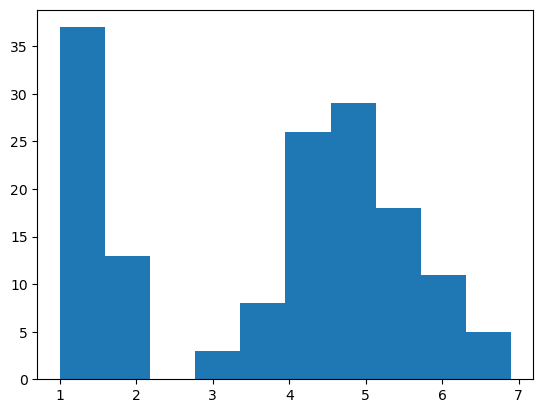

In [31]:
plt.hist(df['petal length (cm)'])
plt.show()

In [32]:
#loadingt the iris dataset
X,Y= iris.data[:, :2],  iris.target


In [33]:
#preprocessing the data#

In [39]:
#partitioning our data into training and testing sets#
X_train,X_test, Y_train,Y_test = train_test_split(X,Y,random_state = 33)

In [40]:
scaler = preprocessing.StandardScaler().fit(X_train)

In [48]:
#transforming the dataset to fit a neigbor classifier#
x_train = scaler.transform(X_train)
x_test = scaler.transform(X_test)


In [49]:
#creating the KNeigbors Model#
Knn = neighbors.KNeighborsClassifier(n_neighbors = 5)

In [50]:
#fitting the model to the data sets#
model=Knn.fit(X_train,Y_train)


In [51]:
#predicting response variables#
Y_pred = model.predict(X_test)
Y_pred

array([1, 2, 0, 2, 1, 2, 0, 0, 2, 2, 2, 0, 2, 1, 2, 2, 1, 0, 2, 2, 0, 0,
       1, 0, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1])

In [52]:
#the model is active and working well as can be seen from the above predicted classes#


In [53]:
#evaluation of the model performance#

In [54]:
#checking the model accuracy#
test_accuracy = print('TestAccuracy:', accuracy_score(Y_test,Y_pred))
test_accuracy

TestAccuracy: 0.631578947368421


In [55]:
train_accuracy = print('TrainAccuracy:',accuracy_score(Y_train,model.predict(X_train)))
train_accuracy

TrainAccuracy: 0.875


In [56]:
#the ratio of 'True Positive' and 'True negative' predictions to all positive and negative observations is 0.63,
#meaning the model  prediction is 63% moderately correct.

In [57]:
#printing the cassification report from the model#
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.40      0.55      0.46        11
           2       0.67      0.53      0.59        19

    accuracy                           0.63        38
   macro avg       0.69      0.69      0.68        38
weighted avg       0.66      0.63      0.64        38



In [58]:
# precision: the ratio of positive predicted labels that are actually positive #
#the model has preidcted the label '0' i.e 'setosa' 100% as it is really is. Also has made a  42% precision of the label '1' i.e 'versicolor' this is a mediocre.
#and finally the label '2' i.e 'virginia' has been decently predicted by 73% from the model just as it is actually observed.

#recall: the ability of the model to predict positive labels out of the actual positives#
#the model has made a beter prediction of both the '0' and '2 labels.
#f1-score:this gives an equal weights to both the 'precision' and 'recall' for measuring the model performance. it is the alternative to accuracy metrics.

In [59]:
#checking on  the confusion matrix to see some posible predictions mistakes of the model#
from sklearn.metrics import confusion_matrix
conf =  print(confusion_matrix(Y_test,Y_pred))

[[ 8  0  0]
 [ 0  6  5]
 [ 0  9 10]]


In [60]:
#from the matrix above, the columns represents the actual instances and the rows are the predicted, in addition the diagonal is the number of samples
#the model has predicted to be correct#
#the label '0' represents the "setosa" speices been predicted by the model:
# from the first row the predicted were correct with a sample of size 8 and the secon with 3 samples wrongly predidted respectively.
#the second row  also has its correct prediction with samples of size 11 being corredt and 8  being wrong respectively.
#the total number of correct predictions made by the model can be express as [ 8+8+8] = 24. Hence the correct number of predicted samples is 24 out 
#of the 50 samples of the setosa species.